In [ ]:
# # Install required packages from requirements.txt
# import subprocess
# import sys
# from pathlib import Path

# # List of packages to install (excluding git packages)
# packages = [
#     "qiskit==1.4.2",
#     "qutip==5.1.1",
#     "qiskit_dynamics==0.5.1",
#     "qiskit_aer==0.17.0",
#     "scikit-learn",
#     "scipy",
#     "networkx",
# ]

# for package in packages:
#     try:
#         print(f"Installing {package}...")
#         subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
#     except:
#         print(f"  (skipped or already installed)")
        
# print("Installation complete!")

Installing qiskit==1.4.2...



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Installing qutip==5.1.1...



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Installing qiskit_dynamics==0.5.1...


...


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Installing scipy...



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Installing networkx...
Installation complete!



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
# Import required packages
import qiskit
import qiskit_dynamics
import qiskit_aer
import qutip
import numpy as np
import matplotlib.pyplot as plt

In [8]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / "src"

sys.path.append(str(SRC_PATH))

from qrc.config import get_default_config
from qrc.setup import setup_qrc_system
from qrc.utils import log_negativity_qt

In [9]:
cfg = get_default_config()

cfg

{'f0': 1.75,
 'Js': 0.5,
 'gamma_scale': 0.2,
 't_final': 25.0,
 't_equi': 0.0,
 'delta_t': 0.024999999999999998,
 'n_qubits': 8,
 'n_steps': 1002,
 't_eval': array([0.0000000e+00, 2.4975025e-02, 4.9950050e-02, ..., 2.4950050e+01,
        2.4975025e+01, 2.5000000e+01], shape=(1002,)),
 't_span': [0.0, 25.0],
 'n_bet': 300,
 'Delta_t': 7.499999999999999,
 'n_injects': 3,
 'n_samples': 10,
 'DeltaDelta_t': 0.7499999999999999,
 'n_data': 30,
 'h_z': 1.5,
 'gamma': 0.01}

In [10]:
system = setup_qrc_system(
    n_qubits=cfg["n_qubits"],
    f0=cfg["f0"],
    gamma_scale=cfg["gamma_scale"],
    coupling_strength=cfg["Js"],
    h_z=cfg["h_z"],
    gamma=cfg["gamma"],
    t_final=cfg["t_final"],
    delta_t=cfg["delta_t"],
    n_samples=cfg["n_samples"],
    n_injects=cfg["n_injects"],
)

system.keys()

dict_keys(['x_ops', 'y_ops', 'z_ops', 'x_mat', 'y_mat', 'z_mat', 'identity', 'zeros', 'rho_0_op', 'rho_0', 't_eval', 't_span', 'sequences', 'sk1', 'sk2', 'coupling_matrices', 'J', 'J_x', 'H', 'L_ops', 'L_mat', 'reservoir_z'])

In [11]:
H = system["H"]
rho_0 = system["rho_0"]
L_mat = system["L_mat"]
sk1 = system["sk1"]
sk2 = system["sk2"]
reservoir_z = system["reservoir_z"]

print("H shape:", H.shape)
print("rho_0 shape:", rho_0.shape)
print("Number of Lindblad operators:", len(L_mat))
print("sk1 shape:", sk1.shape)
print("reservoir_z shape:", reservoir_z.shape)

H shape: (256, 256)
rho_0 shape: (256, 256)
Number of Lindblad operators: 8
sk1 shape: (1002,)
reservoir_z shape: (8, 10, 3)


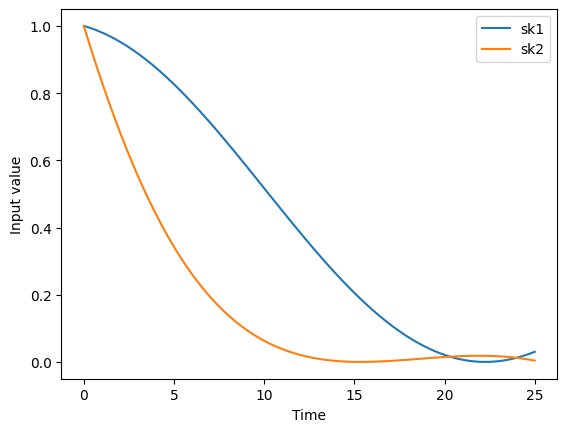

In [12]:
import matplotlib.pyplot as plt

plt.plot(system["t_eval"], sk1, label="sk1")
plt.plot(system["t_eval"], sk2, label="sk2")
plt.xlabel("Time")
plt.ylabel("Input value")
plt.legend()
plt.show()

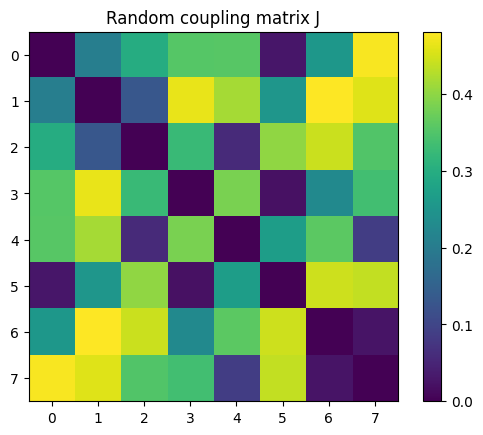

In [13]:
J = system["J"]

plt.imshow(J)
plt.colorbar()
plt.title("Random coupling matrix J")
plt.show()